In [4]:
with open("shakespear.txt","r") as f:
  data = f.read()

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

In [104]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [6]:
vocab = sorted(list(set(data)))
vocab_size = len(vocab)

In [7]:
stoi = {lett:i for i,lett in enumerate(vocab)}
itos = {i:lett for lett,i in stoi.items()}

In [8]:
def encode(x):
  return [stoi[i] for i in x]

def decode(x):
  return ''.join([itos[i] for i in x])

In [9]:
data_enc = torch.tensor(encode(data), dtype = torch.long)
data_enc.shape

torch.Size([1115394])

In [142]:
batch_size = 32
n_embed = 128
block_size = 64
num_head = 4
head_size = 32
dropout = 0.1

In [143]:
nin_per = int(len(data_enc) * 0.9)
train_data = data_enc[:nin_per]
val_data = data_enc[nin_per:]

In [144]:
def get_batch(mode):
  data = train_data if mode == 'train' else val_data
  ix = torch.randint(0, len(data)-block_size-1, (batch_size,))
  xb = torch.stack([data[i: i+block_size] for i in ix]).to(device)
  yb = torch.stack([data[i+1: i+block_size+1] for i in ix]).to(device)
  return xb, yb

In [145]:
xb, yb = get_batch('train')
xb.shape
yb.shape

torch.Size([32, 64])

In [146]:
class Bigram(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, n_embed)
        self.lh1 = nn.Linear(n_embed, vocab_size)
        self.pos_embed = nn.Embedding(block_size, n_embed)
        self.head1 = Head(n_embed)
        self.mha = MultiHeadAttn(num_head, head_size) #this should return a b,t,n_embed
        #self.layer = Block(num_head, head_size, n_embed)
        self.blocks = nn.Sequential(
            Block(num_head, head_size, n_embed),
            Block(num_head, head_size, n_embed),
            Block(num_head, head_size, n_embed),
            Block(num_head, head_size, n_embed),
            nn.LayerNorm(n_embed)
        )

    def forward(self, idx, targets=None): #idx is (B, T) if [[0,31]] shape is [1,2][b,t]
        B, T = idx.shape
        tok_emb = self.embed(idx) # (B,T,C) after embed normally is (B,T,n_emebd)
        pos_emb = self.pos_embed(torch.arange(T, device=idx.device)) #just plucks out till T row from pos_embed (T, n_embed) broadcastbale
        inp = tok_emb + pos_emb #b,t,n_embed goes in
        #h1 = self.head1(inp)
        #sa = self.mha(inp) # we send a b,t,n_embed that becomes b,t,head_sizwes and concat
        block = self.blocks(inp)
        logits = self.lh1(block)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C) # same number of rows in logits and targets collapse batch and each token so just a
            targets = targets.view(B*T)  # big column of 65 rows now one row is softmaxed its label is the next token
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_tokens):
        for _ in range(max_tokens):
            idx_cond = idx[:, -block_size:]
            logit, loss = self(idx_cond)
            logit = logit[:, -1, :] # take all batches wihich means nothing here take the last T which is what matters and all of its dimensions
            probs = F.softmax(logit, dim = -1)
            samp_idx = torch.multinomial(probs, num_samples = 1)
            idx = torch.cat((idx, samp_idx), dim=1)

        return idx

In [147]:
model= Bigram(vocab_size).to(device)

In [148]:
logits, loss= model(xb, yb)

In [156]:
print(decode((model.generate(torch.zeros((1, 1), dtype=torch.long, device=device), 500))[0].tolist()))


John Duke of Gloucester, kneel, respite with a gout,
You so a wrongedice, or life there be my scure?
We will speak with him cleful as streament
Did great daught his sway rape and his breath
The cassing that thou 'Sweep'st sith 'Held me.
Happy days of Kenrating Pown,
And in quariet would the reymour of the common,
Nor cilward which I was lawful daily till myself redeem'd.

HASTINGS:
Iffer'd with the nothing of it of
Ethoutable Clarence, Edward Buckingbroke, if
thou hadst a with promotion; if, I s


In [150]:
optimizer = optim.AdamW(model.parameters(), lr = 1e-3)

In [151]:
losses = []

1.3785971403121948



PAULINA:
The father
Or leaves have a door,
Ralf away ogl to gind thy commandy.

GRER:
Why can you proud what, I say, by someting.
How shall my night? hark them death. But butt when we'll you say to
zase Hereford, Reanluctio. Was the corolds, if presently.

AETESPETER CAPULET:
O man, the case patient
An Echorsene those amburnes monatory,
As too lings, weep our food neme?

ANTIGONUS:
O since I lower, 'tis, go faceed,'
Lest your cament that good for Dukely here.
You have stol'n urged yields, a-loo
1.237880825996399


She doth rattemper it: but quarrectingle--O Montague!
My shame! what knowing agwarty
Is your shielding wither'd by the country haste:
His aunt repent
To my prick'd frown sgrier, he surest that
In her maid.

BUCKINGHAM:
I will abodon the harm.

First Citizen:
Long--the Aumerle gentleman, whom, what were of every
top and of miscratmen shake alike, out way,
And thou nothing crown'd my father's found,
In hopes of that on him sense his name's instals.

KING H

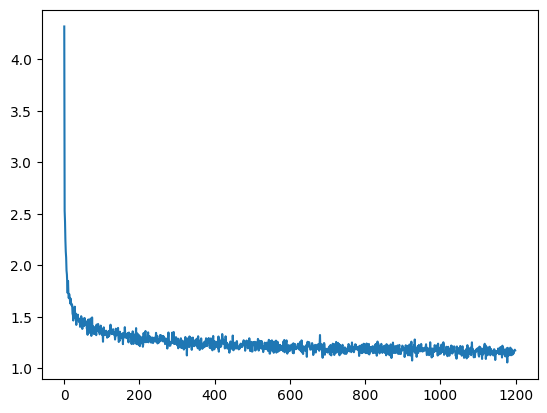

In [152]:
for i in range(120000):

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)

    #B,T,C = logits.shape
    #logits = logits.view(B*T, C)
    #tar = yb.view(B*T)

    #loss = F.cross_entropy(logits, tar)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 100 == 0:
      losses.append(loss.item())

    if i%10000 == 0 and i>0:
        print(loss.item())
        print()
        print(decode((model.generate(torch.zeros((1, 1), dtype=torch.long, device=device), 500))[0].tolist()))
        checkpoint = {
            'iter': i,
            'model_weights': model.state_dict(),
            'optim_weights': optimizer.state_dict(),
            'loss': loss.item()
        }
        torch.save(checkpoint, f'checkpoint_{i}.pt')


print(loss.item())
plt.plot(losses)

In [17]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        #gets in a T, n_embed make it T, head_size
        self.wq = nn.Linear(n_embed, head_size, bias = False)
        self.wk = nn.Linear(n_embed, head_size, bias = False)
        self.wv = nn.Linear(n_embed, head_size, bias = False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B,T,C = x.shape # batch, T is full 8 in training and C is the n_embed

        query = self.wq(x) # b,t,c @ c,head --> b,t,head
        key = self.wk(x) # same thinf as above b,t,head so b,head,t @b,t,head transposeing

        attn_pattern = query @ key.transpose(-1,-2) * C**-0.5 #b,head,head
        attn_pattern_mask = attn_pattern.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        attn_softmax = F.softmax(attn_pattern_mask, dim = -1) #b,t,t

        value = self.wv(x) #b,t,head
        head_op = attn_softmax @ value
        return head_op #b,t,head


In [18]:
class MultiHeadAttn(nn.Module):
    def __init__(self, num_head, head_size):
        super().__init__()
        self.head = nn.ModuleList([Head(head_size) for _ in range(num_head)])
        self.proj = nn.Linear(n_embed, n_embed) #to blend the glued up heads
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([heads(x) for heads in self.head], dim = -1) #we send b,t,n_embed we get concated b,t,head_size
        out = self.proj(out)
        out = self.drop(out)
        return out

In [19]:
class Feedforward(nn.Module):
    def __init__(self, n_embed):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embed, n_embed * 4),
            nn.ReLU(),
            nn.Linear(n_embed *4, n_embed),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # this thing gets (B, T, n_embed)
        x = self.net(x) #return (B, T, n_embed)
        return x

In [20]:
class Block(nn.Module):
    def __init__(self, num_head, head_size, n_embed):
        super().__init__()

        self.mha = MultiHeadAttn(num_head, head_size) #gets in a T, n_embed
        #this calls Head whicht akes the n_embed and downproject it to head_size
        self.ffn = Feedforward(n_embed)
        self.ln1 = nn.LayerNorm(n_embed)
        self.ln2 = nn.LayerNorm(n_embed)

    def forward(self, x):
        x =  x + self.mha(self.ln1(x)) # returns T, n_embed, also added residual additions , layernorm it and then send it
        x =  x + self.ffn(self.ln2(x)) # takes in a T,n_embed @ n_embed, n_embed --> T, n_embed
        # just make it T, vocab_size take last row and sammple
        return x

In [103]:
summ = 0
for i in model.parameters():
  summ += i.numel()
summ

931521